# 6CS012 - Artificial Intelligence and Machine Learning
## Part III
### Dataset: SMS Spam vs Ham Collection


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Step 1: Install and Import Libraries

In [5]:
# Install required libraries (run this in Google Colab)
!pip install nltk wordcloud gensim --quiet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


---
## Step 2: Load and Explore the Dataset

In [7]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/AI FINAL ASSESSMENT/spamvsham.csv', encoding='latin-1', usecols=[0, 1])
df.columns = ['label', 'message']

print('Shape of dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape of dataset: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# Basic info
print('Dataset Info:')
print(df.info())
print('\nNull values:')
print(df.isnull().sum())
print('\nLabel distribution:')
print(df['label'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Null values:
label      0
message    0
dtype: int64

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


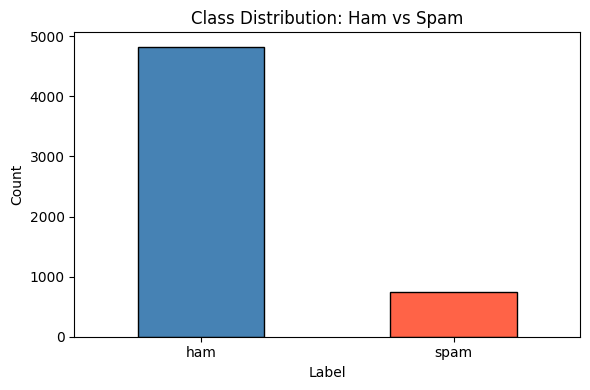

Ham: 4825 | Spam: 747


In [9]:
# Visualise class distribution
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Class Distribution: Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Ham:', (df['label'] == 'ham').sum(), '| Spam:', (df['label'] == 'spam').sum())

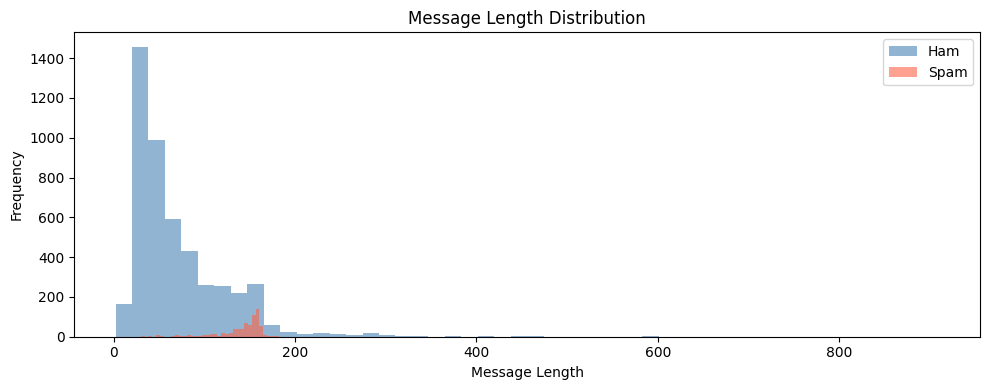

In [10]:
# Message length analysis
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(10, 4))
df[df['label'] == 'ham']['message_length'].plot(kind='hist', bins=50, alpha=0.6, color='steelblue', label='Ham')
df[df['label'] == 'spam']['message_length'].plot(kind='hist', bins=50, alpha=0.6, color='tomato', label='Spam')
plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 3: Text Preprocessing and Cleaning

In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 5. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # 6. Handle contractions
    contractions = {
        "don't": "do not", "can't": "cannot", "won't": "will not",
        "i'm": "i am", "it's": "it is", "i've": "i have",
        "you're": "you are", "we're": "we are", "they're": "they are"
    }
    for k, v in contractions.items():
        text = text.replace(k, v)
    # 7. Remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['cleaned'] = df['message'].apply(clean_text)

print('Original:', df['message'][0])
print('Cleaned: ', df['cleaned'][0])

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:  go jurong point crazy available bugis n great world la e buffet cine got amore wat


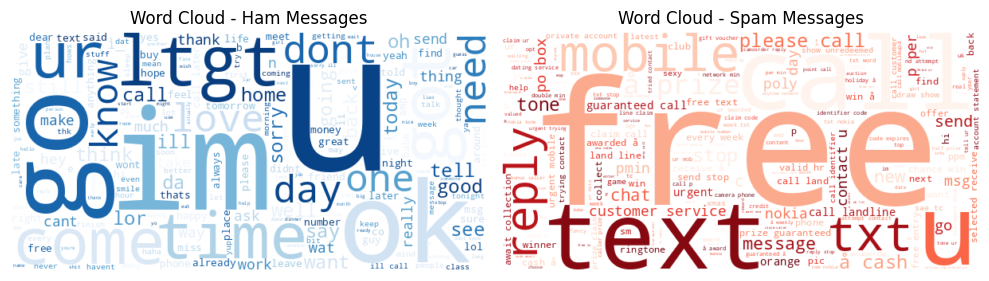

In [12]:
# Word Cloud for Ham messages
ham_text = ' '.join(df[df['label'] == 'ham']['cleaned'])
wordcloud_ham = WordCloud(width=600, height=300, background_color='white', colormap='Blues').generate(ham_text)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Word Cloud - Ham Messages')
plt.axis('off')

# Word Cloud for Spam messages
spam_text = ' '.join(df[df['label'] == 'spam']['cleaned'])
wordcloud_spam = WordCloud(width=600, height=300, background_color='white', colormap='Reds').generate(spam_text)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Word Cloud - Spam Messages')
plt.axis('off')

plt.tight_layout()
plt.show()

---
## Step 4: Tokenization, Label Encoding, and Padding

In [13]:
# Encode labels: ham = 0, spam = 1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Train-test split (80/20)
X = df['cleaned'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples: ', len(X_test))

Training samples: 4457
Testing samples:  1115


In [14]:
# Tokenization
MAX_WORDS = 5000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print('Padding length (95th percentile):', MAX_LEN)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary size:', vocab_size)
print('X_train shape:', X_train_pad.shape)
print('X_test shape: ', X_test_pad.shape)

Padding length (95th percentile): 20
Vocabulary size: 6991
X_train shape: (4457, 20)
X_test shape:  (1115, 20)


---
## Step 5: Model 1 — Simple RNN with Trainable Embedding

In [15]:
model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN))
model1.add(SimpleRNN(64, return_sequences=False))
model1.add(Dropout(0.3))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('Model 1 training complete!')

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9407 - loss: 0.1896 - val_accuracy: 0.9641 - val_loss: 0.1213
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9840 - loss: 0.0678 - val_accuracy: 0.9753 - val_loss: 0.0964
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9910 - loss: 0.0366 - val_accuracy: 0.9798 - val_loss: 0.0920
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9930 - loss: 0.0290 - val_accuracy: 0.9753 - val_loss: 0.1285
Epoch 5/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9938 - loss: 0.0288 - val_accuracy: 0.9529 - val_loss: 0.2112
Epoch 6/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9960 - loss: 0.0217 - val_accuracy: 0.9664 - val_loss: 0.1236
Model 1 training complete!


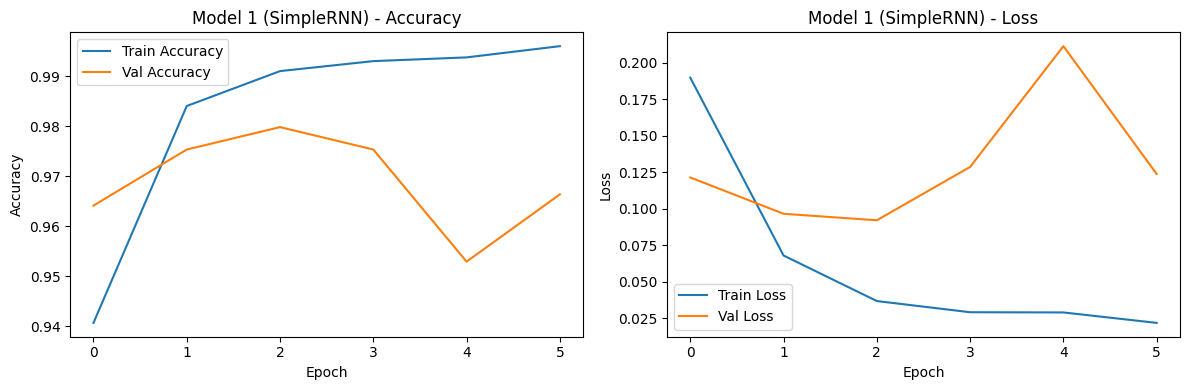

In [17]:
# Plot training curves for Model 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history1.history['accuracy'], label='Train Accuracy')
axes[0].plot(history1.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model 1 (SimpleRNN) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history1.history['loss'], label='Train Loss')
axes[1].plot(history1.history['val_loss'], label='Val Loss')
axes[1].set_title('Model 1 (SimpleRNN) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
=== Model 1: Simple RNN ===
Accuracy: 0.9730941704035875

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.82      0.89       149

    accuracy                           0.97      1115
   macro avg       0.97      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



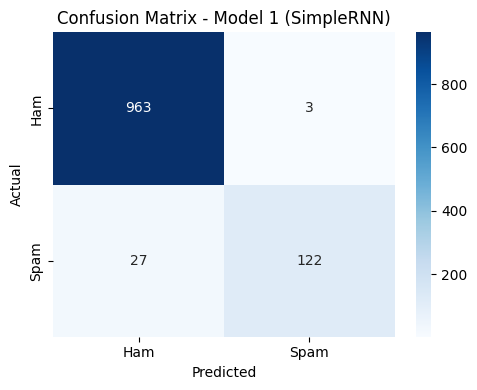

In [18]:
# Evaluate Model 1
y_pred1 = (model1.predict(X_test_pad) > 0.5).astype(int).flatten()

print('=== Model 1: Simple RNN ===')
print('Accuracy:', accuracy_score(y_test, y_pred1))
print('\nClassification Report:')
print(classification_report(y_test, y_pred1, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Model 1 (SimpleRNN)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Step 6: Model 2 — LSTM with Trainable Embedding

In [19]:
model2 = Sequential(name='LSTM_Model')
model2.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN))
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print('Model 2 training complete!')

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9252 - loss: 0.2238 - val_accuracy: 0.9686 - val_loss: 0.1021
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9890 - loss: 0.0442 - val_accuracy: 0.9686 - val_loss: 0.1041
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9943 - loss: 0.0222 - val_accuracy: 0.9821 - val_loss: 0.0946
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9958 - loss: 0.0197 - val_accuracy: 0.9776 - val_loss: 0.1539
Epoch 5/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9970 - loss: 0.0137 - val_accuracy: 0.9574 - val_loss: 0.1979
Epoch 6/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9990 - loss: 0.0047 - val_accuracy: 0.9686 - val_loss: 0.1599
Model 2 training complete!


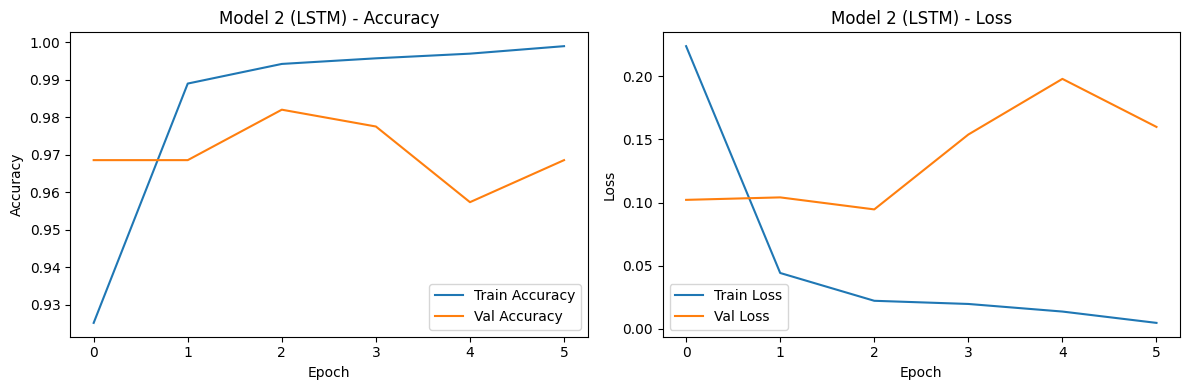

In [21]:
# Plot training curves for Model 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history2.history['accuracy'], label='Train Accuracy')
axes[0].plot(history2.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model 2 (LSTM) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history2.history['loss'], label='Train Loss')
axes[1].plot(history2.history['val_loss'], label='Val Loss')
axes[1].set_title('Model 2 (LSTM) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== Model 2: LSTM ===
Accuracy: 0.9811659192825112

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



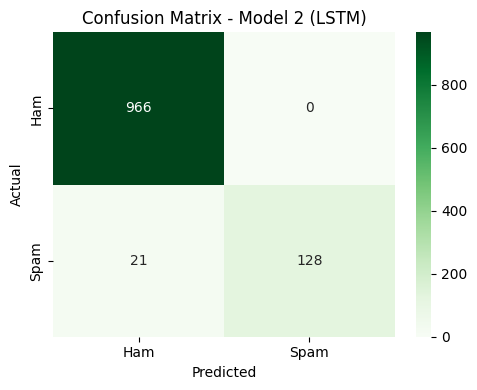

In [22]:
# Evaluate Model 2
y_pred2 = (model2.predict(X_test_pad) > 0.5).astype(int).flatten()

print('=== Model 2: LSTM ===')
print('Accuracy:', accuracy_score(y_test, y_pred2))
print('\nClassification Report:')
print(classification_report(y_test, y_pred2, target_names=['Ham', 'Spam']))

cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Model 2 (LSTM)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Step 7: Model 3 — LSTM with Pretrained Word2Vec (GloVe) Embeddings

In [23]:
# Install gensim with compatible numpy
!pip install numpy==1.23.5 --quiet
!pip install gensim --quiet
print('Gensim installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 122.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Gensim installed!


In [24]:
import gensim.downloader as api

# Load pretrained GloVe embeddings (50 dimensions)
print('Downloading GloVe embeddings... this may take a few minutes')
embedding_model = api.load('glove-wiki-gigaword-50')
print('GloVe embeddings loaded!')

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded!


In [25]:
# Build embedding matrix
EMBEDDING_DIM = 50
word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
found = 0
for word, i in word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            found += 1

print(f'Words found in GloVe: {found} out of {len(word_index)}')
print('Embedding matrix shape:', embedding_matrix.shape)

Words found in GloVe: 5074 out of 6990
Embedding matrix shape: (6991, 50)


In [26]:
# Build Model 3
model3 = Sequential(name='LSTM_GloVe_Model')
model3.add(Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False  # Freeze pretrained weights
))
model3.add(LSTM(64, return_sequences=False))
model3.add(Dropout(0.3))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       349,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,550 (1.33 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 349,550 (1.33 MB)

In [27]:
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print('Model 3 training complete!')

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9195 - loss: 0.2466 - val_accuracy: 0.9529 - val_loss: 0.1300
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9634 - loss: 0.1174 - val_accuracy: 0.9596 - val_loss: 0.1110
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9693 - loss: 0.0923 - val_accuracy: 0.9686 - val_loss: 0.0974
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9761 - loss: 0.0783 - val_accuracy: 0.9641 - val_loss: 0.1074
Epoch 5/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9783 - loss: 0.0641 - val_accuracy: 0.9664 - val_loss: 0.1015
Epoch 6/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9838 - loss: 0.0522 - val_accuracy: 0.9731 - val_loss: 0.0922
Epoch 7/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9860 - loss: 0.0454 - val_accuracy: 0.9664 - val_loss: 0.1215
Epoch 8/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9878 - loss: 0.0405 - val_accuracy:

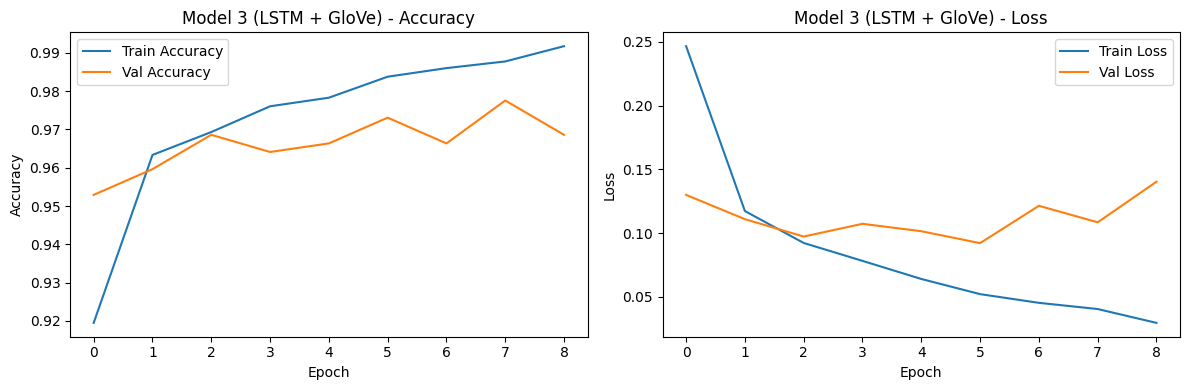

In [28]:
# Plot training curves for Model 3
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history3.history['accuracy'], label='Train Accuracy')
axes[0].plot(history3.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model 3 (LSTM + GloVe) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history3.history['loss'], label='Train Loss')
axes[1].plot(history3.history['val_loss'], label='Val Loss')
axes[1].set_title('Model 3 (LSTM + GloVe) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== Model 3: LSTM + GloVe Embeddings ===
Accuracy: 0.967713004484305

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98       966
        Spam       0.86      0.91      0.88       149

    accuracy                           0.97      1115
   macro avg       0.92      0.94      0.93      1115
weighted avg       0.97      0.97      0.97      1115



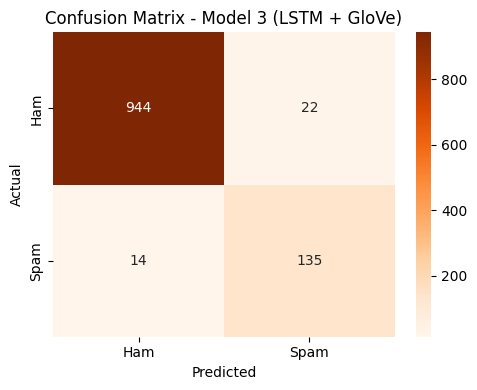

In [29]:
# Evaluate Model 3
y_pred3 = (model3.predict(X_test_pad) > 0.5).astype(int).flatten()

print('=== Model 3: LSTM + GloVe Embeddings ===')
print('Accuracy:', accuracy_score(y_test, y_pred3))
print('\nClassification Report:')
print(classification_report(y_test, y_pred3, target_names=['Ham', 'Spam']))

cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Model 3 (LSTM + GloVe)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Step 8: Compare All 3 Models

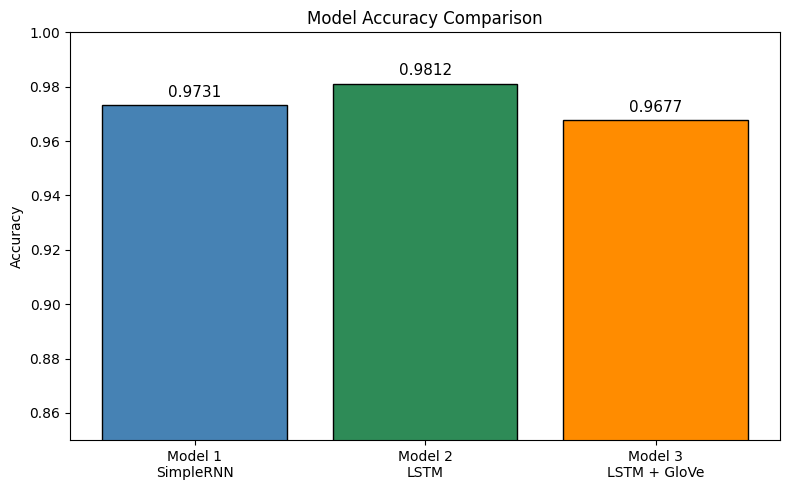

Model 1 (SimpleRNN) Accuracy : 0.9731
Model 2 (LSTM)      Accuracy : 0.9812
Model 3 (LSTM+GloVe)Accuracy : 0.9677


In [30]:
# Accuracy comparison
acc1 = accuracy_score(y_test, y_pred1)
acc2 = accuracy_score(y_test, y_pred2)
acc3 = accuracy_score(y_test, y_pred3)

models = ['Model 1\nSimpleRNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accuracies = [acc1, acc2, acc3]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen', 'darkorange'], edgecolor='black')
plt.ylim(0.85, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Model 1 (SimpleRNN) Accuracy : {acc1:.4f}')
print(f'Model 2 (LSTM)      Accuracy : {acc2:.4f}')
print(f'Model 3 (LSTM+GloVe)Accuracy : {acc3:.4f}')

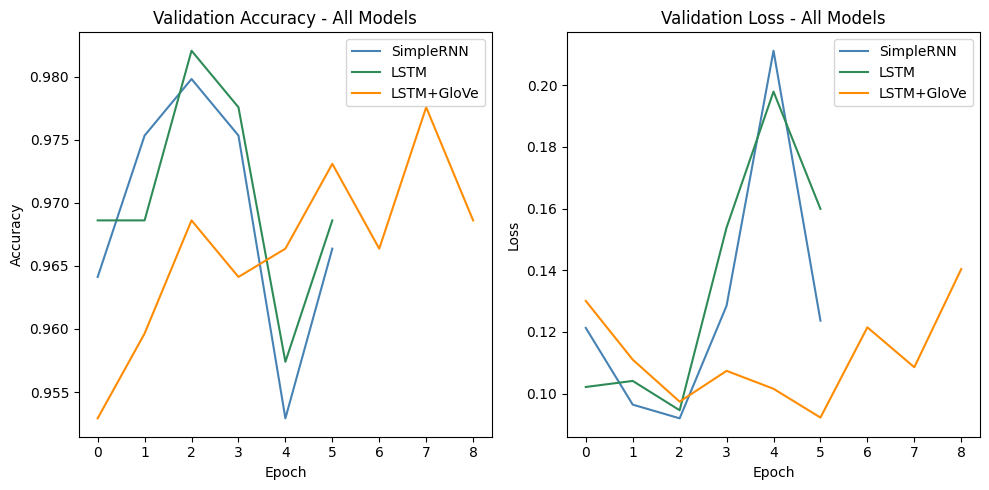

In [31]:
# Compare all 3 training accuracy curves on one plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history1.history['val_accuracy'], label='SimpleRNN', color='steelblue')
plt.plot(history2.history['val_accuracy'], label='LSTM', color='seagreen')
plt.plot(history3.history['val_accuracy'], label='LSTM+GloVe', color='darkorange')
plt.title('Validation Accuracy - All Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['val_loss'], label='SimpleRNN', color='steelblue')
plt.plot(history2.history['val_loss'], label='LSTM', color='seagreen')
plt.plot(history3.history['val_loss'], label='LSTM+GloVe', color='darkorange')
plt.title('Validation Loss - All Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

---
## Step 9: Error Analysis

In [32]:
# Find misclassified examples from best model (Model 2 or 3)
# Using Model 2 for error analysis
test_df = pd.DataFrame({
    'original_message': X_test,
    'actual': y_test,
    'predicted': y_pred2
})

# Get wrong predictions
errors = test_df[test_df['actual'] != test_df['predicted']].reset_index(drop=True)
print(f'Total misclassified: {len(errors)} out of {len(y_test)}')
print()

label_map = {0: 'Ham', 1: 'Spam'}

# Show 3 misclassified examples
for i in range(min(3, len(errors))):
    print(f'--- Error {i+1} ---')
    print(f'Message  : {errors["original_message"][i]}')
    print(f'Actual   : {label_map[errors["actual"][i]]}')
    print(f'Predicted: {label_map[errors["predicted"][i]]}')
    print()

Total misclassified: 21 out of 1115

--- Error 1 ---
Message  : freemsg hey darling week word back id like fun still tb ok xxx std chgs send å rcv
Actual   : Spam
Predicted: Ham

--- Error 2 ---
Message  : hi ur lookin saucy daytime fun wiv busty married woman free next week chat sort time janinexx callsåminmobsmorelkpoboxhpfl
Actual   : Spam
Predicted: Ham

--- Error 3 ---
Message  : ringtoneking
Actual   : Spam
Predicted: Ham



In [33]:
# Error analysis comments
print('=== Error Analysis ===')
print()
print('Possible reasons for misclassification:')
print('1. Short messages that lack enough context for the model to decide correctly.')
print('2. Spam messages that use informal language similar to normal conversation (ham).')
print('3. Ham messages that contain words commonly found in spam (e.g. free, win, prize).')
print('4. The class imbalance (4825 ham vs 747 spam) may cause the model to be biased towards ham.')
print()
print('Suggested improvements:')
print('- Use class weights during training to handle imbalance.')
print('- Use a bidirectional LSTM to capture context from both directions.')
print('- Fine-tune the GloVe embeddings instead of freezing them.')

=== Error Analysis ===

Possible reasons for misclassification:
1. Short messages that lack enough context for the model to decide correctly.
2. Spam messages that use informal language similar to normal conversation (ham).
3. Ham messages that contain words commonly found in spam (e.g. free, win, prize).
4. The class imbalance (4825 ham vs 747 spam) may cause the model to be biased towards ham.

Suggested improvements:
- Use class weights during training to handle imbalance.
- Use a bidirectional LSTM to capture context from both directions.
- Fine-tune the GloVe embeddings instead of freezing them.


---
## Step 10: Real-Time Prediction Function (Simple GUI with Gradio)

In [34]:
!pip install gradio --quiet
print('Gradio installed!')

Gradio installed!


In [35]:
import gradio as gr

def predict_message(message):
    # Clean the input
    cleaned = clean_text(message)
    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    # Predict using best model (Model 2 - LSTM)
    prob = model2.predict(padded, verbose=0)[0][0]
    label = 'SPAM' if prob > 0.5 else 'HAM (Not Spam)'
    confidence = prob if prob > 0.5 else 1 - prob
    return f'Prediction: {label}\nConfidence: {confidence:.2%}'

# Launch Gradio interface
interface = gr.Interface(
    fn=predict_message,
    inputs=gr.Textbox(lines=3, placeholder='Type your SMS message here...', label='Input Message'),
    outputs=gr.Textbox(label='Prediction Result'),
    title='SMS Spam Detector',
    description='Type any SMS message and the model will predict whether it is SPAM or HAM (not spam).'
)

interface.launch(share=True)  # share=True gives a public link in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8476db6a818c3acea6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
